<h1 align='center'>A Quantitative Analysis of Multimodal Biomarkers in Alzheimer’s Disease</h1>

In this paper, we introduce a quantitative framework to characterize the multimodal biomarker landscape of Alzheimer’s Disease (AD) by integrating molecular (**tau-PET**), structural (**MRI**), clinical (**MMSE** and **CDR**), and genetic (**APOE $\epsilon4$**) data. We quantify the unique and shared information provided by each modality to clarify their respective roles and avoid the redundancy typical of black-box models. Our analysis provides a structured view of cross-modal dependencies, how tau pathology relates to structural neurodegeneration across brain regions, the atrophy-mediated and direct effects of tau on cognition, and the dominant spatiotemporal disease trajectory.

The anatomical domain was restricted to **cortical** and **subcortical** regions with established relevance in AD progression, including the limbic core (hippocampus and amygdala) and associative cortices. Anatomical pruning was applied to improve statistical stability and reduce redundancy. White matter regions were **excluded** to avoid known off-target binding effects in tau-PET imaging. Lateral ventricles were excluded from spatial covariance and mediation analyses, as they primarily reflect secondary ex-vacuo expansion rather than direct pathological burden. The global cerebral cortex aggregate was removed to avoid perfect collinearity with its constituent regional parcels.

## Environment Configuration

In [1]:
%%capture
%pip install numpy
%pip install pandas
%pip install statsmodels
%pip install seaborn
%pip install matplotlib
%pip install scipy
%pip install ipywidgets
%pip install scikit-learn
%pip install git+https://github.com/ucl-pond/pySuStaIn

In [2]:
import os
import sys
sys.path.append(os.path.abspath('../src'))

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy import stats, ndimage
from sklearn.utils import resample
from sklearn.preprocessing import scale
from statsmodels.stats.multitest import multipletests

from sustain import SustainEngine
from utils import spearman_age
from utils import plot_histograms
from utils import standardized_residuals
from utils import get_mediation_stats_controlled
from utils import calculate_diagnostic_separability
from utils import calculate_mi, calculate_multivariate_r2
from utils import get_residuals_scaled, fit_pls, bootstrap_pls_interactions

In [4]:
sns.set_theme(style='whitegrid', context='paper')

In [5]:
DEFAULT_COLORMAP = 'coolwarm'
DEFAULT_COLOR = '#4F6367'
SEX_PALETTE = ['#DB5461', '#4A7ED1']
DIAGNOSIS_PALETTE = ['#466362', '#77AF9C', '#B32624']
APOE_PALETTE = ['#2A3D45', '#FFC145', '#D63230']
SUSTAIN_PALETTE = ['#1458EB', '#7C837C', '#E8A922']

To isolate the anatomical structures most susceptible to AD, the **3D brain MRI** scans were automatically segmented using **SynthSeg**. This deep-learning tool mapped the cortical and subcortical volumes according to the **Desikan-Killiany atlas**. From this comprehensive parcellation, we strategically extracted a targeted subset of Regions of Interest (**ROIs**) that closely align with the established **Braak staging** of neurofibrillary tangle progression. By restricting our anatomical domain to these specific limbic and associative areas, we focus the multimodal analysis exclusively on the regions most vulnerable to AD neurodegeneration, effectively reducing statistical noise from non-relevant brain structures.

In [6]:
ROI = [
    'hippocampus', 'amygdala',
    'entorhinal', 'inferiortemporal',
    'middletemporal', 'fusiform',
    'inferiorparietal', 'precuneus', 'posteriorcingulate'
]

tau_cols = [roi + '_mean_uptake' for roi in ROI]
vol_cols = [roi + '_volume' for roi in ROI]

## Exploratory Data Analysis

In [7]:
df = pd.read_csv('../data/dataset_normalized.csv')
df = df.drop_duplicates(subset='subject_id', keep='last')
print('Cross-sectional dataset composed of', len(df), 'samples.')
print('We selected', len(ROI), 'ROIs from the Desikan-Killiany atlas.')

Cross-sectional dataset composed of 789 samples.
We selected 9 ROIs from the Desikan-Killiany atlas.


### Age Distribution

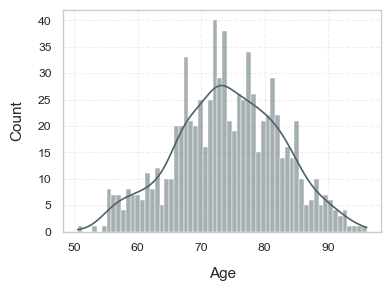

In [8]:
plt.figure(figsize=(4, 3))
sns.histplot(df['age'], kde=True, bins=60, color=DEFAULT_COLOR)
plt.xlabel('Age', fontsize=11, labelpad=10)
plt.ylabel('Count', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Sex Distribution

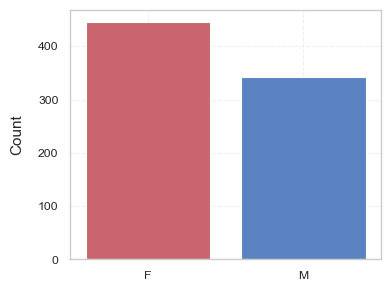

In [9]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='sex', order=df['sex'].value_counts().index, hue='sex', palette=SEX_PALETTE)
plt.xlabel('', fontsize=11, labelpad=10)
plt.ylabel('Count', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Diagnosis Distribution

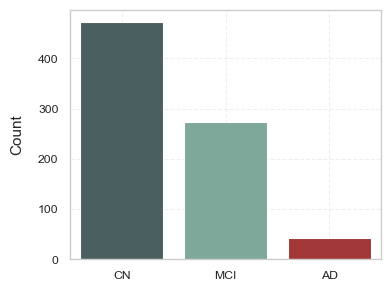

In [10]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='diagnosis', order=df['diagnosis'].value_counts().index, hue='diagnosis', palette=DIAGNOSIS_PALETTE)
plt.xlabel('', fontsize=11, labelpad=10)
plt.ylabel('Count', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### APOE $\epsilon4$ genotype Distribution

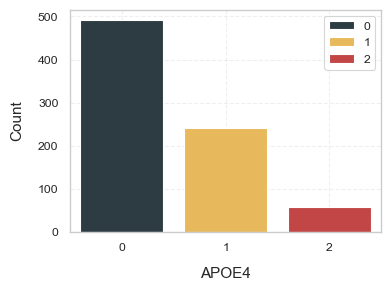

In [11]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='apoe4_dose', order=df['apoe4_dose'].value_counts().index, hue='apoe4_dose', palette=APOE_PALETTE)
plt.xlabel('APOE4', fontsize=11, labelpad=10)
plt.ylabel('Count', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

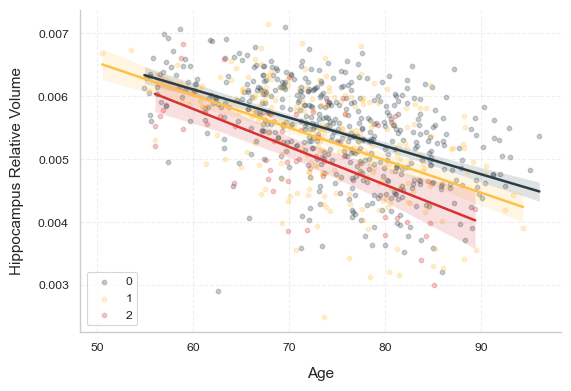

In [12]:
sns.lmplot(data=df, x='age', y='hippocampus_volume', hue='apoe4_dose', palette=APOE_PALETTE, height=4, aspect=1.45, scatter_kws={'alpha': 0.25, 's': 10}, legend=False)
plt.xlabel('Age', fontsize=11, labelpad=10)
plt.ylabel('Hippocampus Relative Volume', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Uptake Distribution

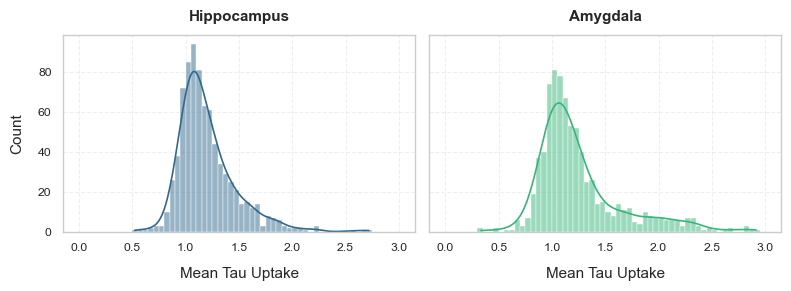

In [13]:
plot_histograms(
    df=df,
    columns=['hippocampus_mean_uptake', 'amygdala_mean_uptake'],
    titles=['Hippocampus', 'Amygdala'],
    xlabel='Mean Tau Uptake',
    bins=60,
    binrange=(0.0, 3.0),
    sharex=True,
    figsize=(8, 3),
    palette='viridis'
)

### Volumes Distribution

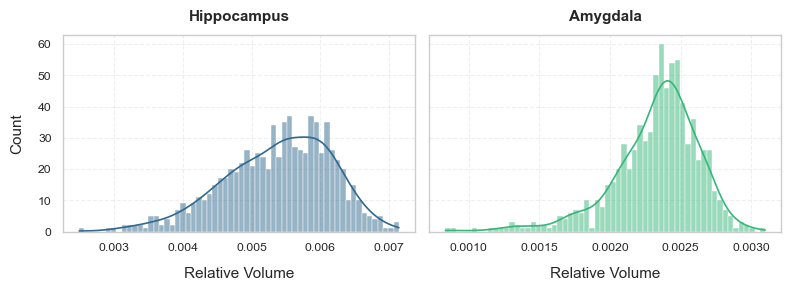

In [14]:
plot_histograms(
    df=df,
    columns=['hippocampus_volume', 'amygdala_volume'],
    titles=['Hippocampus', 'Amygdala'],
    xlabel='Relative Volume',
    bins=60,
    figsize=(8, 3),
    palette='viridis'
)

### CDR-GLOBAL Distribution

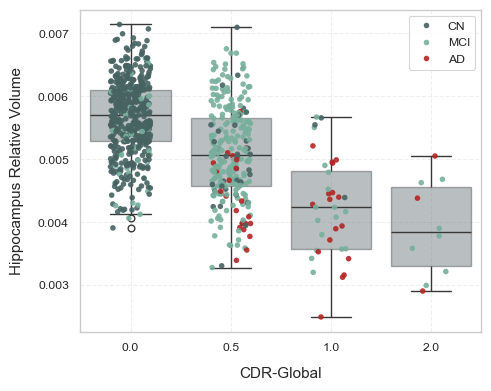

In [15]:
plt.figure(figsize=(5, 4))
sns.boxplot(x='cdr_global', y='hippocampus_volume', data=df, boxprops={'alpha': 0.4}, color=DEFAULT_COLOR)
sns.stripplot(x='cdr_global', y='hippocampus_volume', data=df, hue='diagnosis', palette=DIAGNOSIS_PALETTE, alpha=0.9, size=4, jitter=0.2)
plt.xlabel('CDR-Global', fontsize=11, labelpad=10)
plt.ylabel('Hippocampus Relative Volume', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### MMSE and CDR-SB Distributions

In [16]:
print('Separability Scores (AUC) in the range [0, 1]')
calculate_diagnostic_separability(df, 'mmse')
calculate_diagnostic_separability(df, 'cdr_sb')

Separability Scores (AUC) in the range [0, 1]
mmse | CN vs MCI = 0.7111618647860373
mmse | CN vs AD = 0.9861572535991141
mmse | MCI vs AD = 0.9144073687869309
cdr_sb | CN vs MCI = 0.9090831931605994
cdr_sb | CN vs AD = 0.9935064935064936
cdr_sb | MCI vs AD = 0.8978102189781023


## Validation of Pathophysiological Associations

Before delving into complex multimodal interactions, it is essential to validate the pathophysiological coherence of our dataset to ensure that it accurately reflects known biological mechanisms. This validation phase builds a reliable foundation for our subsequent models. Specifically, we **first** verify whether the neurostructural and cognitive metrics exhibit plausible trajectories of decline with advancing age. **Finally**, by isolating the variance explained by age, sex, and regional tau accumulation, we confirm the expected biological premise that the APOE $\epsilon4$ variant does not confer an independent structural vulnerability. This validates that although the APOE $\epsilon4$ genotype strongly predisposes individuals to upstream amyloid-beta deposition, at equivalent levels of regional tau burden, structural atrophy remains strictly comparable between carriers and non-carriers, ensuring our framework accurately mirrors clinical realities.

### Assessing Biological Plausibility of Age-Related Changes in Brain and Cognitive Measures

In [17]:
features_of_interest = tau_cols + vol_cols + ['cdr_global', 'cdr_sb', 'mmse']
res_df = pd.DataFrame(map(lambda f: spearman_age(df, f), features_of_interest), columns=['feature', 'spearman_rho', 'p_value'])
res_df['significant'] = multipletests(res_df['p_value'], method='fdr_bh')[0]
display(res_df)

,feature,spearman_rho,p_value,significant
0,hippocampus_mean_uptake,0.287,0.00000,True
1,amygdala_mean_uptake,0.302,0.00000,True
2,entorhinal_mean_uptake,0.164,0.00000,True
3,inferiortemporal_mean_uptake,0.160,0.00001,True
4,middletemporal_mean_uptake,0.111,0.00184,True
5,fusiform_mean_uptake,0.278,0.00000,True
6,inferiorparietal_mean_uptake,0.057,0.10817,False
7,precuneus_mean_uptake,0.189,0.00000,True
8,posteriorcingulate_mean_uptake,0.143,0.00006,True
9,hippocampus_volume,-0.524,0.00000,True


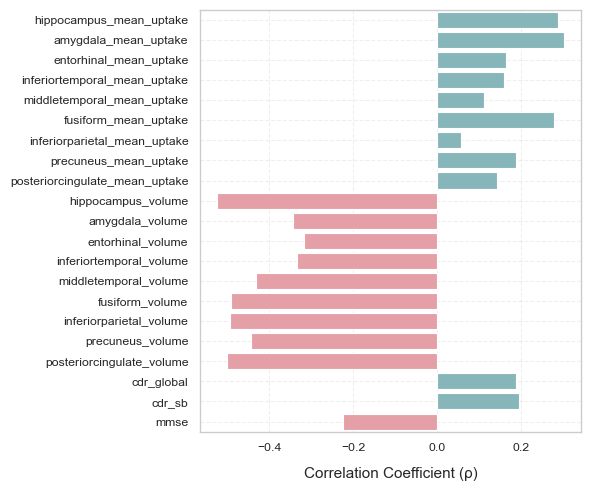

In [18]:
colors = ['#7EBDC2' if r > 0 else '#EF959D' for r in res_df['spearman_rho']]
plt.figure(figsize=(6, 5))
sns.barplot(data=res_df, x='spearman_rho', y='feature', hue='feature', palette=colors, dodge=False, legend=False)
plt.xlabel('Correlation Coefficient (ρ)', fontsize=11, labelpad=10)
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### APOE $\epsilon4$ genotype Does Not Increase Atrophy Vulnerability at Equal Tau Levels

In [19]:
X_covariates = df[['age', 'sex']].copy()
X_covariates['sex'] = X_covariates['sex'].map({'M': 0, 'F': 1})
residuals_df = standardized_residuals(df, vol_cols, X_covariates, add_constant=True)
df['global_vulnerability_index'] = residuals_df.mean(axis=1)
vuln_carriers = df.loc[df['apoe4_carrier'] == 1, 'global_vulnerability_index']
vuln_non_carriers = df.loc[df['apoe4_carrier'] == 0, 'global_vulnerability_index']

t_stat, p_val = stats.ttest_ind(vuln_carriers, vuln_non_carriers, equal_var=False)
print('t-test =', t_stat.round(4))
print('p-value =', p_val.round(4))

t-test = -3.4595
p-value = 0.0006


## Multimodal Analysis

AD is a highly complex pathology that cannot be fully captured by a single clinical or biological marker. Consequently, multimodal integration has become a standard in predictive modeling, yet the specific informational overlap between different modalities often remains a black box. In this section, we systematically analyze the multimodal landscape to understand the unique and shared information each biomarker provides. We quantify **information redundancy** using Normalized Mutual Information and evaluate the cross-modal **predictive capacity** through explained. Furthermore, we map the intra-regional associations between tau accumulation and structural atrophy, subsequently extracting robust cross-regional patterns via Partial Least Squares Singular Value Decomposition (PLS-SVD). These insights offer a quantitative rationale for feature selection, helping to design more interpretable models by avoiding highly redundant inputs and prioritizing complementary biological sources. Finally, we decompose the **direct and atrophy-mediated effects** of tau on cognition, and reconstruct the dominant spatiotemporal **disease trajectory** to capture the sequential cascade of biomarker abnormalities. These insights offer a quantitative rationale for feature selection, helping to design more interpretable models by avoiding highly redundant inputs and prioritizing complementary biological sources.

In [20]:
modalities_data = {
    'APOE4': df['apoe4_dose'],
    'PET (Tau)': df[tau_cols],
    'MRI (Volumes)': df[vol_cols],
    'MMSE': df['mmse'],
    'CDR-SB': df['cdr_sb'],
    'CDR-GLOB': df['cdr_global']
}

labels = list(modalities_data.keys())
mi_matrix = pd.DataFrame(np.zeros((len(labels), len(labels))), index=labels, columns=labels)
nmi_matrix = pd.DataFrame(np.zeros((len(labels), len(labels))), index=labels, columns=labels)
r2_matrix_raw = pd.DataFrame(np.zeros((len(labels), len(labels))), index=labels, columns=labels)
alpha_matrix = pd.DataFrame(np.zeros((len(labels), len(labels))), index=labels, columns=labels)

for pred_label in labels:
    for target_label in labels:
        mi_matrix.loc[pred_label, target_label] = calculate_mi(modalities_data[pred_label], modalities_data[target_label])
        best_alpha, r2 = calculate_multivariate_r2(modalities_data[pred_label], modalities_data[target_label])
        r2_matrix_raw.loc[pred_label, target_label] = r2
        alpha_matrix.loc[pred_label, target_label] = best_alpha

### Quantifying Cross-Modal Information Redundancy

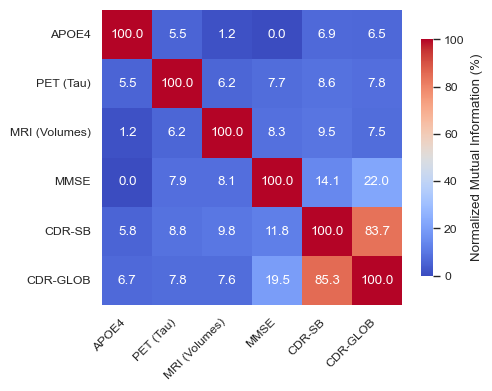

In [21]:
entropy = np.diag(mi_matrix)
for i, pred in enumerate(labels):
    for j, target in enumerate(labels):
        norm = min(entropy[i], entropy[j])
        nmi_matrix.iloc[i,j] = (mi_matrix.iloc[i,j] / norm if norm > 0 else 0)

plt.figure(figsize=(5, 4))
sns.heatmap(nmi_matrix * 100, annot=True, fmt='.1f', cmap=DEFAULT_COLORMAP, cbar_kws={'label': 'Normalized Mutual Information (%)', 'shrink': 0.8})
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()
plt.show()

### Estimating Cross-Modal Predictive Capabilities

In [22]:
display(alpha_matrix)

,APOE4,PET (Tau),MRI (Volumes),MMSE,CDR-SB,CDR-GLOB
APOE4,0.000100,17.886495,509.413801,54.622772,65.793322,65.793322
PET (Tau),138.488637,0.000100,45.348785,65.793322,37.649358,37.649358
MRI (Volumes),242.012826,95.454846,0.000100,65.793322,37.649358,65.793322
MMSE,54.622772,31.257158,21.544347,0.000100,0.000100,2.782559
CDR-SB,95.454846,21.544347,17.886495,1.917910,0.000100,1.917910
CDR-GLOB,95.454846,14.849683,12.328467,1.321941,0.000100,0.000100


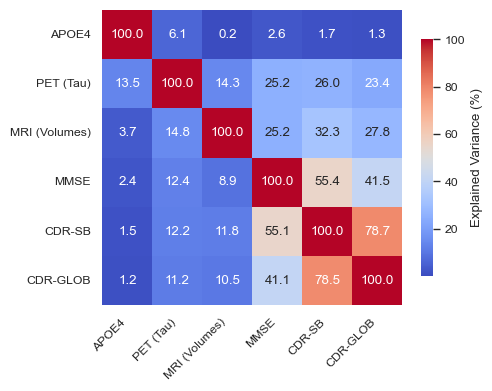

In [23]:
plt.figure(figsize=(5, 4))
sns.heatmap(r2_matrix_raw * 100, annot=True, fmt='.1f', cmap=DEFAULT_COLORMAP, cbar_kws={'label': 'Explained Variance (%)', 'shrink': 0.8})
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()
plt.show()

### Intra-Regional Structure-Pathology Associations

In [24]:
results = [ stats.pearsonr(df[t], df[v]) for t, v in zip(tau_cols, vol_cols) ]
intra_r = [ res[0] for res in results ]
intra_p = [ res[1] for res in results ]
is_significant = multipletests(intra_p, alpha=0.05, method='fdr_bh')[0]
df_intra = pd.DataFrame({ 'region': ROI, 'pearson_r': intra_r, 'significant': is_significant }).sort_values('pearson_r', ascending=True)
display(df_intra)

,region,pearson_r,significant
1,amygdala,-0.552789,True
0,hippocampus,-0.455530,True
2,entorhinal,-0.326743,True
4,middletemporal,-0.254267,True
5,fusiform,-0.237397,True
3,inferiortemporal,-0.225448,True
7,precuneus,-0.166010,True
6,inferiorparietal,-0.137688,True
8,posteriorcingulate,-0.097742,True


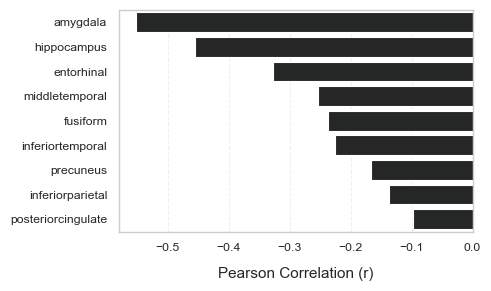

In [25]:
plt.figure(figsize=(5, 3))
sns.barplot(data=df_intra, x='pearson_r', y='region', hue='significant', dodge=False, legend=False, palette='dark:#4F6367')
plt.xlabel('Pearson Correlation (r)', fontsize=11, labelpad=10)
plt.ylabel('')
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Regional Structure-Pathology Associations

In [26]:
X_scaled, Y_scaled = get_residuals_scaled(df, tau_cols, vol_cols, X_covariates)
pls, w_tau_original, w_vol_original = fit_pls(X_scaled, Y_scaled, n_components=1)
interaction_mean, ci_low, ci_high, sig_mask = bootstrap_pls_interactions(X_scaled, Y_scaled, w_tau_original, n_boot=7500, random_state=42)

sig_tau_idx = np.where(sig_mask.any(axis=1))[0]
sig_vol_idx = np.where(sig_mask.any(axis=0))[0]
top_tau_cols = [ tau_cols[i] for i in sig_tau_idx ]
top_vol_cols = [ vol_cols[i] for i in sig_vol_idx ]
print('Mean tau uptake ROIs retained after PLS filtering:', len(top_tau_cols), 'out of', len(tau_cols))
print('Volume ROIs retained after PLS filtering:', len(top_vol_cols), 'out of', len(vol_cols))

Mean tau uptake ROIs retained after PLS filtering: 9 out of 9
Volume ROIs retained after PLS filtering: 9 out of 9


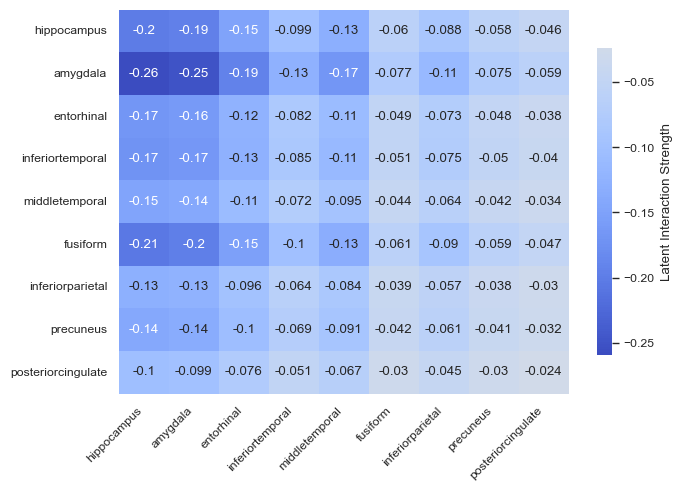

In [27]:
df_interaction = pd.DataFrame(interaction_mean, index=ROI, columns=ROI)
plt.figure(figsize=(7, 5))
sns.heatmap(df_interaction, cmap=DEFAULT_COLORMAP, center=0, annot=True, cbar_kws={'label': 'Latent Interaction Strength', 'shrink': 0.8})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Statistical Decomposition: Direct vs Atrophy-Mediated Effects of Tau

In [28]:
df['tau_idx'] = scale(df[tau_cols]).mean(axis=1)
df['atrophy_idx'] = -scale(df[vol_cols]).mean(axis=1) 
valid_cols = ['tau_idx', 'atrophy_idx', 'cdr_sb', 'age', 'sex']
df_clean = df.dropna(subset=valid_cols).assign(sex=(df['sex'] == 'F').astype(int))

ind_original, dir_original, tot_original = np.round(get_mediation_stats_controlled(df_clean), 3)
boot_results = np.array([get_mediation_stats_controlled(resample(df_clean)) for _ in range(7500)])
ci_ind, ci_dir = np.round(np.percentile(boot_results[:, :2], [2.5, 97.5], axis=0).T, 3)
print('Indirect Effect (ACME) = {} \u00B1 95% CI: [{}, {}]'.format(ind_original.round(3), ci_ind[0].round(3), ci_ind[1].round(3)))
print('Direct Effect (ADE) = {} \u00B1 95% CI: [{}, {}]'.format(dir_original.round(3), ci_dir[0].round(3), ci_dir[1].round(3)))
print('Total Effect =', tot_original.round(3))

Indirect Effect (ACME) = 0.284 ± 95% CI: [0.197, 0.384]
Direct Effect (ADE) = 0.722 ± 95% CI: [0.546, 0.907]
Total Effect = 1.006


### Reconstructing the Dominant Spatiotemporal Disease Trajectory

In [29]:
num_biomarkers = len(top_tau_cols) + len(top_vol_cols)
num_events = num_biomarkers * 3
num_phenotypes = 1

z_map = {
    'tau': {'stages': [1, 2, 3], 'max_score': 5},
    'vol': {'stages': [2, 3, 4], 'max_score': 6}
}

engine = SustainEngine(df, top_tau_cols, top_vol_cols, output_dir='../sustain_outputs/', z_map=z_map)
engine.apply_normative_modeling()
df_results, samples_sequence = engine.fit_and_assign(n_subtypes=num_phenotypes, iterations=int(1e5))
ordered_bio_idx, ordered_labels, expected = engine.get_biomarker_order(samples_sequence, subtype=0)

Running final MCMC training on 1 latent trajectories...
Found pickle file: ../sustain_outputs/pickle_files/AD_Final_Model_subtype0.pickle. Using pickled variables for 0 subtype.


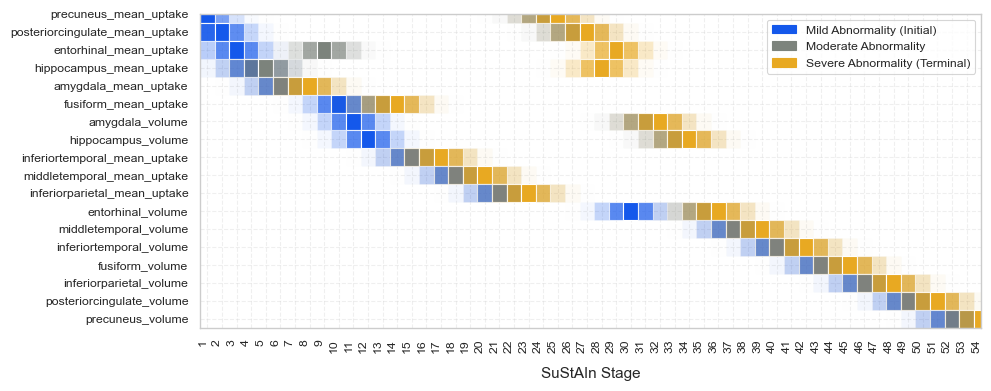

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
legend_patches = [
    mpatches.Patch(color=SUSTAIN_PALETTE[0], label='Mild Abnormality (Initial)'),
    mpatches.Patch(color=SUSTAIN_PALETTE[1], label='Moderate Abnormality'),
    mpatches.Patch(color=SUSTAIN_PALETTE[2], label='Severe Abnormality (Terminal)')
]

for y, biomarker in enumerate(ordered_bio_idx):
    for z, color in enumerate(SUSTAIN_PALETTE):
        event = biomarker + z * num_biomarkers
        probs = ndimage.gaussian_filter1d(np.mean(samples_sequence[:, :, 0]==event, axis=0), 1.2)
        probs = probs / probs.max() if probs.max() > 0 else probs
        for stage, prob in enumerate(probs):
            ax.add_patch(mpatches.Rectangle((stage, num_biomarkers-1-y), 1, 1, facecolor=color, alpha=prob))

ax.set_xticks(np.arange(num_events) + 0.5)
ax.set_xticklabels(np.arange(1, num_events + 1), rotation=90, ha='right')
ax.set_xlabel('SuStAIn Stage', fontsize=11, labelpad=10)
ax.set_yticks(np.arange(num_biomarkers) + 0.5)
ax.set_yticklabels(ordered_labels[::-1])
ax.legend(handles=legend_patches, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

In conclusion, this systematic quantitative analysis successfully deconstructs the multimodal landscape of AD. By quantifying information redundancy and cross-modal explained variance, we established the complementary diagnostic value of each modality. Our FDR-corrected intra-regional correlations and PLS-SVD cross-decomposition mapped both the localized and systemic patterns through which tau accumulation correlates with widespread brain atrophy. Furthermore, our statistical decomposition resolved the clinical hierarchy: tau pathology exhibits a substantial direct association with cognitive impairment, with a smaller fraction of this decline being indirectly mediated by macroscopic volume loss. For Medical AI research, these discoveries provide a transparent, biologically informed foundation for feature selection. Modality selection should prioritize complementary biological sources rather than maximizing the number of inputs, ultimately guiding the design of more efficient and interpretable multimodal architectures.